# ARTI 403 - Lab 2

## Import Libraries

In [23]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import skimage as ski

## Images

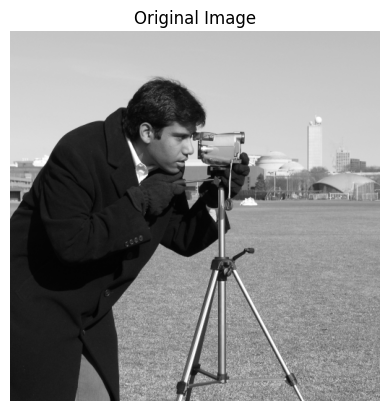

In [24]:
images_dir = Path('images')
images_dir.mkdir(exist_ok=True)

camera_path = images_dir / 'camera.png'
coins_path = images_dir / 'coins.png'

Image.fromarray(ski.data.camera()).save(camera_path)
Image.fromarray(ski.data.coins()).save(coins_path)

original_image = cv2.imread(str(camera_path), cv2.IMREAD_GRAYSCALE)

if original_image is None:
    raise FileNotFoundError('Image could not be loaded.')

plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

## Image Sampling and Quantization

In [25]:
def sample_image(image, factor):
    height, width = image.shape[:2]
    new_width = max(1, width // factor)
    new_height = max(1, height // factor)
    return cv2.resize(
        image, (new_width, new_height), interpolation=cv2.INTER_NEAREST
    )


def quantize_image(image, levels):
    step = 255 / (levels - 1)
    quantized = np.round(image.astype(np.float32) / step) * step
    return np.clip(quantized, 0, 255).astype(np.uint8)


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray', vmin=0, vmax=255)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray', vmin=0, vmax=255)
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray', vmin=0, vmax=255)
    plt.title('Quantized Image')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

## Task 1 - Change the Parameters

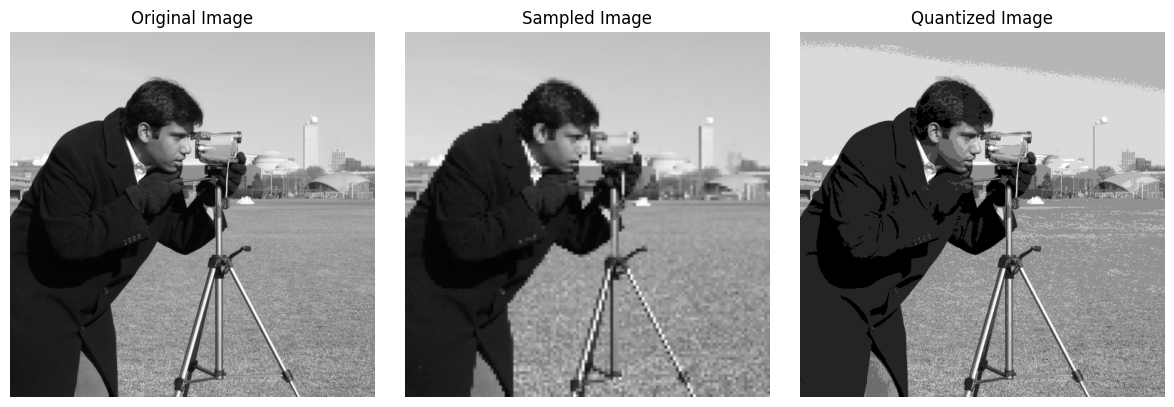

In [26]:
sampling_factor = 4
quantization_levels = 8

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

## Task 2 - Read Two Images

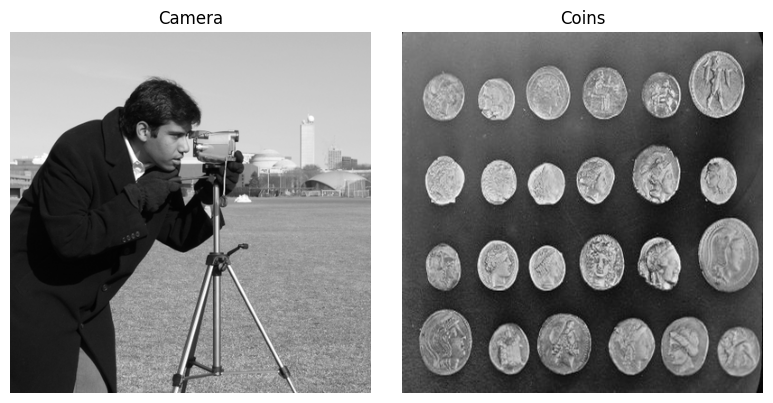

In [27]:
img1 = Image.open(camera_path).convert('L')
img2 = Image.open(coins_path).convert('L')

size = (400, 400)
img1 = img1.resize(size, Image.Resampling.LANCZOS)
img2 = img2.resize(size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1, dtype=np.uint8)
im2arr = np.asarray(img2, dtype=np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(im1arr, cmap='gray')
axes[0].set_title('Camera')
axes[1].imshow(im2arr, cmap='gray')
axes[1].set_title('Coins')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Subtract Two Images

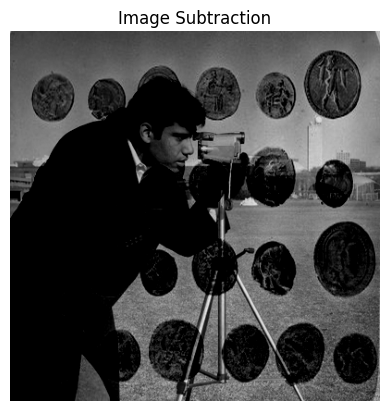

In [28]:
subtraction = cv2.subtract(im1arr, im2arr)

plt.imshow(subtraction, cmap='gray', vmin=0, vmax=255)
plt.title('Image Subtraction')
plt.axis('off')
plt.show()

### Add 175 to an Image

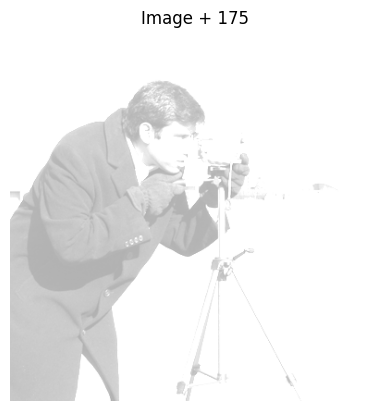

In [29]:
constant = np.full_like(im1arr, 175)
addition = cv2.add(im1arr, constant)

plt.imshow(addition, cmap='gray', vmin=0, vmax=255)
plt.title('Image + 175')
plt.axis('off')
plt.show()

### Binary Images

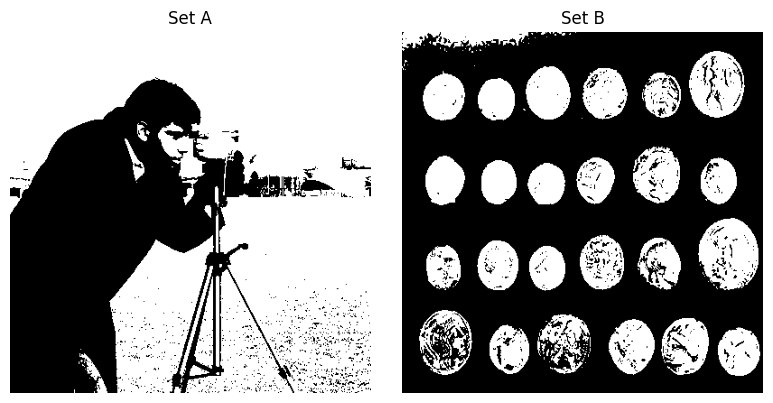

In [30]:
_, set_a = cv2.threshold(im1arr, 127, 255, cv2.THRESH_BINARY)
_, set_b = cv2.threshold(im2arr, 127, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(set_a, cmap='gray')
axes[0].set_title('Set A')
axes[1].imshow(set_b, cmap='gray')
axes[1].set_title('Set B')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Set Difference

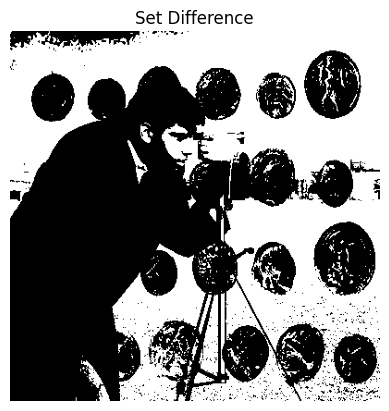

In [31]:
difference = cv2.bitwise_and(set_a, cv2.bitwise_not(set_b))

plt.imshow(difference, cmap='gray')
plt.title('Set Difference')
plt.axis('off')
plt.show()

### Symmetric Difference

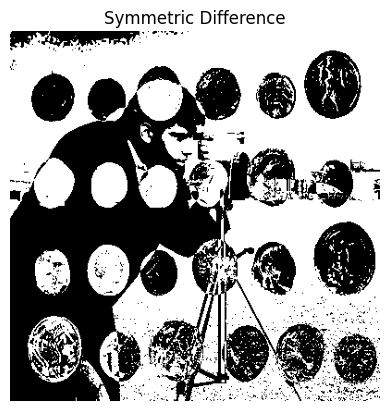

In [32]:
symmetric_difference = cv2.bitwise_xor(set_a, set_b)

plt.imshow(symmetric_difference, cmap='gray')
plt.title('Symmetric Difference')
plt.axis('off')
plt.show()

### Intersection

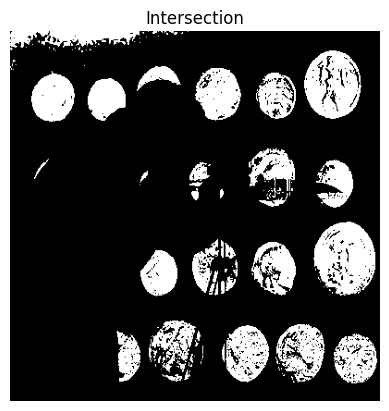

In [33]:
intersection = cv2.bitwise_and(set_a, set_b)

plt.imshow(intersection, cmap='gray')
plt.title('Intersection')
plt.axis('off')
plt.show()